<a href="https://colab.research.google.com/github/bharathgowdap12-oss/-EDA-Retail-Sales-Analysis/blob/main/DA_project2_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

# List of zip files to extract
zip_files = ['/content/apps.csv.zip', '/content/user_reviews.csv.zip']

# Directory to extract files to (current directory)
extract_to_dir = '/content/'

for zip_file_path in zip_files:
    if os.path.exists(zip_file_path):
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to_dir)
        print(f"Extracted '{zip_file_path}' to '{extract_to_dir}'")
    else:
        print(f"Warning: '{zip_file_path}' not found. Skipping extraction.")

# Verify that the CSV files now exist
print('\nChecking for extracted CSV files:')
if os.path.exists(os.path.join(extract_to_dir, 'apps.csv')):
    print('apps.csv found.')
else:
    print('apps.csv not found.')

if os.path.exists(os.path.join(extract_to_dir, 'user_reviews.csv')):
    print('user_reviews.csv found.')
else:
    print('user_reviews.csv not found.')

Extracted '/content/apps.csv.zip' to '/content/'
Extracted '/content/user_reviews.csv.zip' to '/content/'

Checking for extracted CSV files:
apps.csv found.
user_reviews.csv found.


In [ ]:
import pandas as pd

apps = pd.read_csv('apps.csv')
reviews = pd.read_csv('user_reviews.csv')

print('Apps DataFrame loaded successfully. First 5 rows:')
display(apps.head())

print('\nReviews DataFrame loaded successfully. First 5 rows:')
display(reviews.head())

Apps DataFrame loaded successfully. First 5 rows:


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



Reviews DataFrame loaded successfully. First 5 rows:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
apps.isnull().sum()

apps.dropna(inplace=True)

In [ ]:
apps['Installs'] = apps['Installs'].astype(str).str.replace('+','', regex=False).str.replace(',','', regex=False)
apps['Installs'] = apps['Installs'].astype(int)

In [ ]:
apps['Price'] = apps['Price'].str.replace('$','')
apps['Price'] = apps['Price'].astype(float)

In [ ]:
apps['Rating'] = apps['Rating'].astype(float)

<Axes: xlabel='Category'>

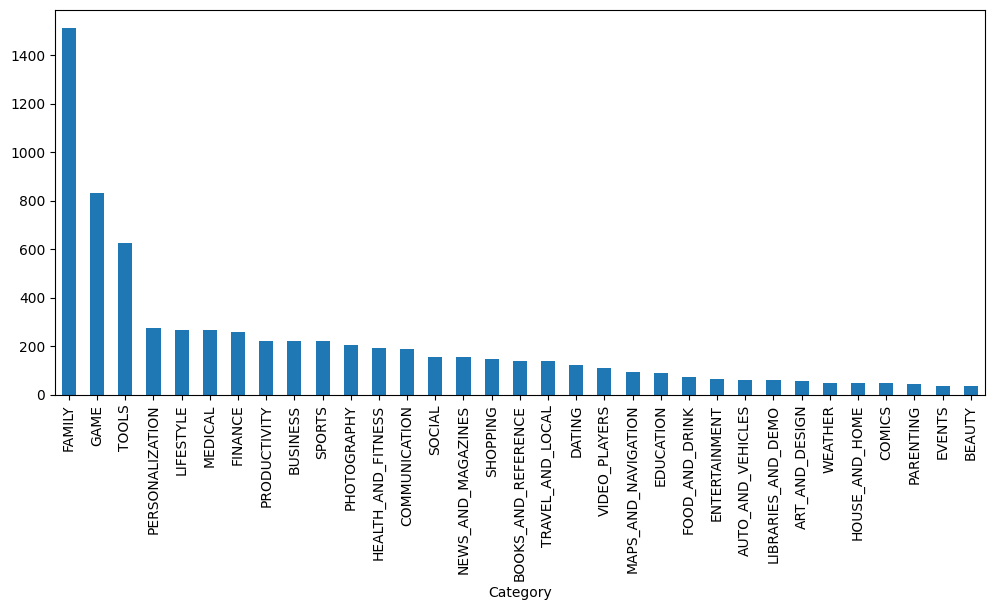

In [ ]:
category_count = apps['Category'].value_counts()

category_count.plot(kind='bar', figsize=(12,5))

<Axes: ylabel='Frequency'>

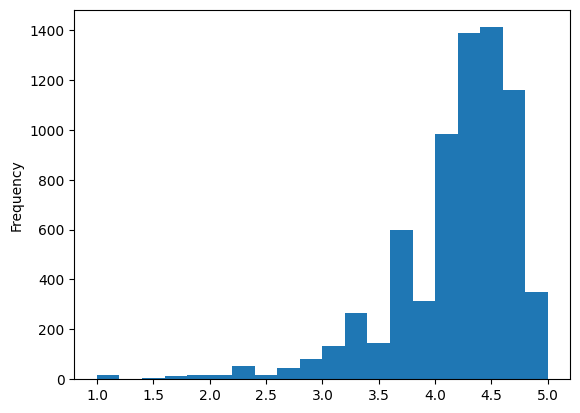

In [ ]:
apps['Rating'].plot(kind='hist', bins=20)

<Axes: xlabel='Rating', ylabel='Installs'>

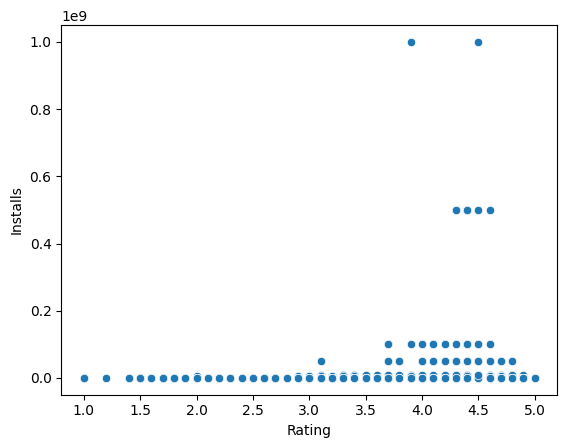

In [ ]:
import seaborn as sns

sns.scatterplot(x='Rating', y='Installs', data=apps)

<Axes: ylabel='count'>

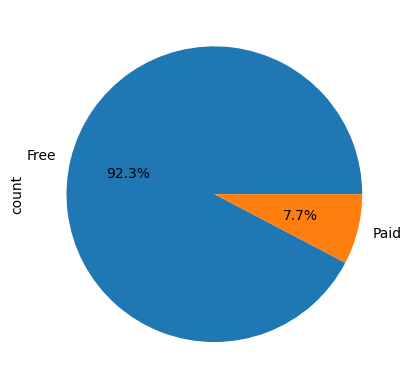

In [ ]:
apps['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: ylabel='Frequency'>

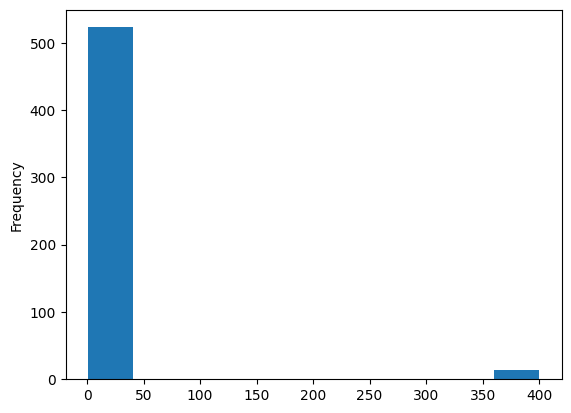

In [ ]:
apps[apps['Price'] > 0]['Price'].plot(kind='hist')

In [ ]:
apps['Size'].head()

,Size
0,19.0
1,14.0
2,8.7
3,25.0
4,2.8


In [ ]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
